# 01: Baseline Accessibility

**Purpose**: Define and compute the status quo accessibility before any new transit corridors.

**Why this notebook matters**:
- Everything later is **relative to this baseline**
- This is the **frozen reference point** for all counterfactual analysis
- If this changes later → something went wrong

**What this notebook does**:
1. Defines the accessibility metric explicitly (formula, parameters, assumptions)
2. Computes baseline accessibility for all tracts
3. Visualizes the baseline (map + distribution)
4. Saves results to disk for reuse in later notebooks

**What this notebook does NOT do**:
- ❌ No synthetic corridors
- ❌ No optimization
- ❌ No demand modeling
- ❌ No counterfactuals

**Checkpoint artifact**: `baseline_accessibility.parquet` + map + distribution plot


## Part 1: Setup and Data Loading

Load data from Notebook 00 (exploration phase).

In [10]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT / "src"))

import config
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from math import radians, cos, sin, asin, sqrt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

print(f"✓ Imports loaded")
print(f"Time threshold (τ): {config.TIME_THRESHOLD} minutes")

✓ Imports loaded
Time threshold (τ): 30 minutes


### Load Tracts, Jobs, Demographics, and Transit Stops

**Implementation Note**: This cell uses the same data loading logic as Notebook 00. 
In a production pipeline, you would load from saved processed data files.

**Data Sources**:
- Census tracts: Shapefile from `data_raw/`
- Jobs: LEHD/LODES WAC file (aggregated to tracts)
- Demographics: Census ACS data
- Transit stops: GTFS feeds (bus + rail)

In [11]:
# Load data using same logic as Notebook 00
print("Loading data...")

# 1. Load Census Tract Geometry
print("  1. Loading census tracts...")
tract_shp = list(config.DATA_RAW.glob("tl_*.shp"))
if tract_shp:
    tracts = gpd.read_file(tract_shp[0])
    # Filter to LA County (county code 037)
    if 'COUNTYFP' in tracts.columns:
        tracts = tracts[tracts['COUNTYFP'] == '037'].copy()
    elif 'GEOID' in tracts.columns:
        tracts = tracts[tracts['GEOID'].str[:5] == '06037'].copy()
    tracts['GEOID'] = tracts['GEOID'].astype(str).str.zfill(11)
    print(f"     ✓ Loaded {len(tracts):,} LA County tracts")
else:
    raise FileNotFoundError("No tract shapefile found")

# 2. Load Job Counts (LEHD/LODES)
print("  2. Loading job data...")
lehd_files = list(config.DATA_RAW.glob("*wac*.csv.gz")) + list(config.DATA_RAW.glob("*wac*.csv"))
if lehd_files:
    jobs_raw = pd.read_csv(lehd_files[0], compression='gzip' if lehd_files[0].suffix == '.gz' else None)
    if 'w_geocode' in jobs_raw.columns and 'C000' in jobs_raw.columns:
        # Extract tract GEOID (first 11 digits of 15-digit geocode)
        jobs_raw['GEOID'] = jobs_raw['w_geocode'].astype(str).str.zfill(15).str[:11]
        # Filter to LA County
        jobs_raw = jobs_raw[jobs_raw['GEOID'].str[:5] == '06037'].copy()
        # Aggregate jobs by tract
        jobs = jobs_raw.groupby('GEOID', as_index=False)['C000'].sum()
        jobs.rename(columns={'C000': 'jobs_total'}, inplace=True)
        jobs['GEOID'] = jobs['GEOID'].astype(str).str.zfill(11)
        # Merge into tracts
        tracts = tracts.merge(jobs[['GEOID', 'jobs_total']], on='GEOID', how='left')
        print(f"     ✓ Loaded jobs for {tracts['jobs_total'].notna().sum():,} tracts")
        print(f"     Total jobs: {tracts['jobs_total'].sum():,.0f}")
    else:
        print("     ⚠ Job columns not found")
        tracts['jobs_total'] = np.nan
else:
    print("     ⚠ No LEHD files found")
    tracts['jobs_total'] = np.nan

# 3. Load Demographics (Census ACS)
print("  3. Loading demographics...")
acs_files = list(config.DATA_RAW.glob("*acs*.csv"))
if acs_files:
    acs = pd.read_csv(acs_files[0])
    # Construct GEOID
    if all(c in acs.columns for c in ['state', 'county', 'tract']):
        acs['GEOID'] = (acs['state'].astype(str).str.zfill(2) + 
                       acs['county'].astype(str).str.zfill(3) + 
                       acs['tract'].astype(str).str.zfill(6))
    # Extract population and income
    if 'B01003_001E' in acs.columns:
        acs['pop_total'] = pd.to_numeric(acs['B01003_001E'], errors='coerce')
    if 'B19013_001E' in acs.columns:
        acs['median_income'] = pd.to_numeric(acs['B19013_001E'], errors='coerce')
        acs['median_income'] = acs['median_income'].replace(-666666666, np.nan)
    if 'GEOID' in acs.columns:
        acs['GEOID'] = acs['GEOID'].astype(str).str.zfill(11)
        tracts = tracts.merge(acs[['GEOID', 'pop_total', 'median_income']], on='GEOID', how='left')
        print(f"     ✓ Loaded demographics for {tracts['pop_total'].notna().sum():,} tracts")
else:
    print("     ⚠ No ACS files found")
    tracts['pop_total'] = np.nan
    tracts['median_income'] = np.nan

# 4. Load Transit Stops (GTFS)
print("  4. Loading transit stops...")
try:
    from ingest import gtfs
    stops = gtfs.ingest_gtfs(data_dir=config.DATA_RAW, save=False)
    print(f"     ✓ Loaded {len(stops):,} transit stops using gtfs module")
except Exception as e:
    print(f"     ⚠ Error using gtfs module: {e}")
    # Manual fallback
    import gtfs_kit as gk
    gtfs_files = list(config.DATA_RAW.glob("*gtfs*.zip"))
    if gtfs_files:
        all_stops = []
        for gtfs_file in gtfs_files:
            try:
                feed = gk.read_feed(gtfs_file, dist_units='km')
                if feed.stops is not None and len(feed.stops) > 0:
                    stops_df = feed.stops.copy()
                    stops_df['mode'] = 'bus' if 'bus' in gtfs_file.name.lower() else 'rail'
                    all_stops.append(stops_df)
            except Exception as e:
                print(f"     ⚠ Error loading {gtfs_file.name}: {e}")
        if all_stops:
            stops_df = pd.concat(all_stops, ignore_index=True)
            stops = gpd.GeoDataFrame(
                stops_df,
                geometry=gpd.points_from_xy(stops_df['stop_lon'], stops_df['stop_lat'], crs=config.GEOGRAPHIC_CRS)
            )
            # Filter to LA County extent
            la_bbox = {'min_lon': -118.7, 'max_lon': -117.9, 'min_lat': 33.7, 'max_lat': 34.8}
            stops = stops.cx[la_bbox['min_lon']:la_bbox['max_lon'], la_bbox['min_lat']:la_bbox['max_lat']]
            print(f"     ✓ Loaded {len(stops):,} transit stops manually")
        else:
            stops = gpd.GeoDataFrame()
    else:
        stops = gpd.GeoDataFrame()

print(f"\n✓ Data loading complete:")
print(f"  Tracts: {len(tracts):,}")
print(f"  Tracts with jobs: {tracts['jobs_total'].notna().sum():,}")
print(f"  Tracts with population: {tracts['pop_total'].notna().sum():,}")
print(f"  Transit stops: {len(stops):,}")

Loading data...
  1. Loading census tracts...
     ✓ Loaded 2,498 LA County tracts
  2. Loading job data...
     ✓ Loaded jobs for 2,494 tracts
     Total jobs: 4,478,164
  3. Loading demographics...
     ✓ Loaded demographics for 2,498 tracts
  4. Loading transit stops...
✓ Loaded bus GTFS: metro_bus_gtfs.zip
✓ Loaded rail GTFS: metro_rail_gtfs.zip
✓ Extracted 12,164 stops
  Bus stops: 11,727
  Rail stops: 437
     ✓ Loaded 12,164 transit stops using gtfs module

✓ Data loading complete:
  Tracts: 2,498
  Tracts with jobs: 2,494
  Tracts with population: 2,498
  Transit stops: 12,164


## Part 2: Accessibility Metric Definition

**This section explicitly defines the accessibility metric. This definition is FROZEN and will not change.**

### Accessibility Formula

The baseline accessibility for tract $i$ is defined as:

$$A_i^{baseline} = \sum_{j} J_j \cdot \mathbf{1}(T_{ij} \leq \tau)$$

Where:
- $A_i^{baseline}$ = baseline accessibility for tract $i$ (total jobs reachable)
- $J_j$ = number of jobs in destination tract $j$
- $T_{ij}$ = travel time from tract $i$ to tract $j$ (minutes)
- $\tau$ = time threshold = **30 minutes** (frozen parameter)
- $\mathbf{1}(T_{ij} \leq \tau)$ = indicator function (1 if travel time ≤ threshold, 0 otherwise)

**Interpretation**: This counts all jobs in destination tracts that are reachable within the time threshold from origin tract $i$.

### Time Threshold (τ)

**Value**: $\tau = 30$ minutes

**Rationale**:
- 30 minutes is a standard commute time threshold in transit accessibility studies
- Represents a reasonable maximum acceptable travel time for most commuters
- Balances between too restrictive (15 min) and too permissive (60 min)
- Allows comparison with other studies using similar thresholds

**This threshold is FROZEN** - all counterfactual analysis will use the same threshold.

### Binary Cutoff (No Distance Decay)

**Decision**: Use binary indicator function (job is either reachable or not)

**Why binary cutoff instead of distance decay**:

1. **Simplicity and transparency**: Easy to understand and explain
   - "How many jobs can I reach in 30 minutes?" is more intuitive than weighted sums

2. **Standard practice**: Most transit accessibility studies use binary thresholds
   - Allows comparison with other studies
   - Avoids parameter tuning (decay functions require choosing decay rate)

3. **Policy relevance**: Transit planners think in terms of "jobs within X minutes"
   - Service standards often use binary thresholds

4. **Computational efficiency**: Binary check is faster than computing decay weights

**Alternative (not used)**: Gravity model with distance decay would weight closer jobs more, but requires choosing decay function parameters.

**This decision is FROZEN** - all analysis uses binary cutoff.

### Travel Time Proxy Method

**Method**: Simplified travel time calculation using nearest transit stops

**Steps**:
1. Find nearest transit stop to origin tract centroid
2. Find nearest transit stop to destination tract centroid
3. Compute straight-line distances and convert to time:
   - Walking speed: 80 m/min (~5 km/h)
   - Transit speed: 500 m/min (~30 km/h)
   - Average wait time: 5 minutes

**Total travel time**:
$$T_{ij} = \frac{d_{walk,origin}}{80} + \frac{d_{transit}}{500} + 5 + \frac{d_{walk,dest}}{80}$$

**Why this simplified method**:
- Pragmatic approximation (full multimodal routing is computationally expensive)
- Sufficient for baseline (captures main patterns)
- Transparent (easy to understand assumptions)
- Standard in literature

**Limitations (acknowledged)**: Uses straight-line distances, assumes direct connections, does not account for GTFS schedules or time-of-day variation.

**This method is FROZEN** - all counterfactual analysis uses the same travel time calculation.

## Part 3: Compute Baseline Accessibility

Compute accessibility for all tracts using the defined metric.

### Step 1: Prepare Tract Centroids

Compute centroids for all tracts (origins) and tracts with jobs (destinations).

In [12]:
# Prepare tract centroids
# IMPORTANT: Compute centroids in projected CRS (UTM) for accuracy, then convert to geographic CRS
print("Preparing tract centroids...")

# Project to UTM Zone 11N for accurate centroid calculation
tracts_projected = tracts.to_crs(config.ANALYSIS_CRS)
tracts_projected['centroid'] = tracts_projected.geometry.centroid

# Convert back to geographic CRS for distance calculations
tracts_geo = tracts_projected.to_crs(config.GEOGRAPHIC_CRS)
tracts_geo['centroid_lon'] = tracts_geo.geometry.centroid.x
tracts_geo['centroid_lat'] = tracts_geo.geometry.centroid.y

# Separate origins (all tracts) and destinations (tracts with jobs)
origins = tracts_geo.copy()
destinations = tracts_geo[tracts_geo['jobs_total'].notna() & (tracts_geo['jobs_total'] > 0)].copy()

print(f"  ✓ Prepared {len(origins):,} origin tracts")
print(f"  ✓ Prepared {len(destinations):,} destination tracts (with jobs)")
print(f"  Total jobs in destinations: {destinations['jobs_total'].sum():,.0f}")
print(f"  Sample origin centroid: ({origins['centroid_lon'].iloc[0]:.4f}, {origins['centroid_lat'].iloc[0]:.4f})")

Preparing tract centroids...
  ✓ Prepared 2,498 origin tracts
  ✓ Prepared 2,494 destination tracts (with jobs)
  Total jobs in destinations: 4,478,164
  Sample origin centroid: (-118.0440, 34.0869)


### Step 2: Find Nearest Transit Stops

For each origin and destination tract, find the nearest transit stop.

In [13]:
# Find nearest transit stops for each origin and destination
# Uses Euclidean distance in geographic coordinates (approximate but fast)
print("Finding nearest transit stops...")

# Ensure stops are in geographic CRS
stops_geo = stops.to_crs(config.GEOGRAPHIC_CRS)

# Get stop coordinates as numpy array
stop_coords = np.array([[stop.x, stop.y] for stop in stops_geo.geometry])

# Find nearest stop for each origin
origin_coords = np.array([[lon, lat] for lon, lat in zip(origins['centroid_lon'], origins['centroid_lat'])])
origin_distances = cdist(origin_coords, stop_coords, metric='euclidean')
origin_nearest_idx = np.argmin(origin_distances, axis=1)
origins['nearest_stop_dist'] = origin_distances[np.arange(len(origins)), origin_nearest_idx]
origins['nearest_stop_lon'] = stop_coords[origin_nearest_idx, 0]
origins['nearest_stop_lat'] = stop_coords[origin_nearest_idx, 1]

# Find nearest stop for each destination
dest_coords = np.array([[lon, lat] for lon, lat in zip(destinations['centroid_lon'], destinations['centroid_lat'])])
dest_distances = cdist(dest_coords, stop_coords, metric='euclidean')
dest_nearest_idx = np.argmin(dest_distances, axis=1)
destinations['nearest_stop_dist'] = dest_distances[np.arange(len(destinations)), dest_nearest_idx]
destinations['nearest_stop_lon'] = stop_coords[dest_nearest_idx, 0]
destinations['nearest_stop_lat'] = stop_coords[dest_nearest_idx, 1]

# Convert distances from degrees to approximate meters (1 degree ≈ 111 km)
# This is approximate but sufficient for our simplified method
origins['nearest_stop_dist_m'] = origins['nearest_stop_dist'] * 111000
destinations['nearest_stop_dist_m'] = destinations['nearest_stop_dist'] * 111000

print(f"  ✓ Found nearest stops for {len(origins):,} origins")
print(f"  ✓ Found nearest stops for {len(destinations):,} destinations")
print(f"  Mean distance to nearest stop (origins): {origins['nearest_stop_dist_m'].mean():.1f} m ({origins['nearest_stop_dist_m'].mean()/1000:.2f} km)")
print(f"  Mean distance to nearest stop (destinations): {destinations['nearest_stop_dist_m'].mean():.1f} m ({destinations['nearest_stop_dist_m'].mean()/1000:.2f} km)")

Finding nearest transit stops...
  ✓ Found nearest stops for 2,498 origins
  ✓ Found nearest stops for 2,494 destinations
  Mean distance to nearest stop (origins): 3560.9 m (3.56 km)
  Mean distance to nearest stop (destinations): 3557.7 m (3.56 km)


### Step 3: Compute Travel Times

Compute travel time matrix between all origin-destination pairs using the simplified method.

In [14]:
# Compute travel time matrix using simplified method
# T_ij = (d_walk_origin / 80) + (d_transit / 500) + 5 + (d_walk_dest / 80)
print(f"Computing travel times (threshold = {config.TIME_THRESHOLD} min)...")
print(f"  This will compute {len(origins):,} × {len(destinations):,} = {len(origins) * len(destinations):,} pairs...")

# Constants (from metric definition)
WALKING_SPEED_M_PER_MIN = 80  # ~5 km/h
TRANSIT_SPEED_M_PER_MIN = 500  # ~30 km/h
AVG_WAIT_TIME_MIN = 5

# Haversine distance function for transit leg (stop to stop)
def haversine_meters(lon1, lat1, lon2, lat2):
    """Calculate great circle distance between two points in meters."""
    R = 6371000  # Earth radius in meters
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    return R * c

# Compute travel time matrix
# For efficiency, we'll compute in chunks if needed
print("  Computing travel time matrix...")

# Get coordinates
origin_stop_coords = np.array([[lon, lat] for lon, lat in zip(origins['nearest_stop_lon'], origins['nearest_stop_lat'])])
dest_stop_coords = np.array([[lon, lat] for lon, lat in zip(destinations['nearest_stop_lon'], destinations['nearest_stop_lat'])])

# Initialize travel time matrix
travel_time_matrix = np.zeros((len(origins), len(destinations)))

# Compute for each origin-destination pair
for i in range(len(origins)):
    if (i + 1) % 100 == 0:
        print(f"    Progress: {i+1}/{len(origins)} origins ({100*(i+1)/len(origins):.1f}%)")
    
    # Walking time: origin to nearest stop
    t_walk_origin = origins.iloc[i]['nearest_stop_dist_m'] / WALKING_SPEED_M_PER_MIN
    
    # Transit distance and time: nearest stop to nearest stop
    origin_stop_lon = origins.iloc[i]['nearest_stop_lon']
    origin_stop_lat = origins.iloc[i]['nearest_stop_lat']
    
    for j in range(len(destinations)):
        dest_stop_lon = destinations.iloc[j]['nearest_stop_lon']
        dest_stop_lat = destinations.iloc[j]['nearest_stop_lat']
        
        # Transit distance (haversine)
        d_transit = haversine_meters(origin_stop_lon, origin_stop_lat, dest_stop_lon, dest_stop_lat)
        t_transit = d_transit / TRANSIT_SPEED_M_PER_MIN
        
        # Walking time: nearest stop to destination
        t_walk_dest = destinations.iloc[j]['nearest_stop_dist_m'] / WALKING_SPEED_M_PER_MIN
        
        # Total travel time
        travel_time_matrix[i, j] = t_walk_origin + t_transit + AVG_WAIT_TIME_MIN + t_walk_dest

print(f"  ✓ Computed travel time matrix: {travel_time_matrix.shape}")
print(f"  Min travel time: {travel_time_matrix.min():.1f} min")
print(f"  Max travel time: {travel_time_matrix.max():.1f} min")
print(f"  Mean travel time: {travel_time_matrix.mean():.1f} min")
print(f"  Median travel time: {np.median(travel_time_matrix):.1f} min")
print(f"  Pairs within {config.TIME_THRESHOLD} min: {(travel_time_matrix <= config.TIME_THRESHOLD).sum():,} ({(travel_time_matrix <= config.TIME_THRESHOLD).sum() / travel_time_matrix.size * 100:.1f}%)")

Computing travel times (threshold = 30 min)...
  This will compute 2,498 × 2,494 = 6,230,012 pairs...
  Computing travel time matrix...
    Progress: 100/2498 origins (4.0%)
    Progress: 200/2498 origins (8.0%)
    Progress: 300/2498 origins (12.0%)
    Progress: 400/2498 origins (16.0%)
    Progress: 500/2498 origins (20.0%)
    Progress: 600/2498 origins (24.0%)
    Progress: 700/2498 origins (28.0%)
    Progress: 800/2498 origins (32.0%)
    Progress: 900/2498 origins (36.0%)
    Progress: 1000/2498 origins (40.0%)
    Progress: 1100/2498 origins (44.0%)
    Progress: 1200/2498 origins (48.0%)
    Progress: 1300/2498 origins (52.0%)
    Progress: 1400/2498 origins (56.0%)
    Progress: 1500/2498 origins (60.0%)
    Progress: 1600/2498 origins (64.1%)
    Progress: 1700/2498 origins (68.1%)
    Progress: 1800/2498 origins (72.1%)
    Progress: 1900/2498 origins (76.1%)
    Progress: 2000/2498 origins (80.1%)
    Progress: 2100/2498 origins (84.1%)
    Progress: 2200/2498 origins (88

### Step 4: Compute Baseline Accessibility

For each origin tract, count jobs in reachable destinations (travel time ≤ threshold).

In [15]:
# Compute baseline accessibility using the defined formula
# A_i = sum(J_j * 1(T_ij <= tau))
print(f"Computing baseline accessibility (τ = {config.TIME_THRESHOLD} min)...")
print(f"  Formula: A_i = Σ J_j · 1(T_ij ≤ {config.TIME_THRESHOLD})")

# Binary indicator: 1 if travel time <= threshold, 0 otherwise
reachable = (travel_time_matrix <= config.TIME_THRESHOLD).astype(int)

# Jobs array for destinations
jobs_array = destinations['jobs_total'].values

# Accessibility = sum of jobs in reachable destinations
# Matrix multiplication: reachable (n_origins × n_dests) × jobs_array (n_dests × 1)
accessibility = np.dot(reachable, jobs_array)

# Add to origins dataframe
origins['accessibility_baseline'] = accessibility

# Also compute per-capita accessibility (jobs per 1,000 residents)
origins['accessibility_per_capita'] = (origins['accessibility_baseline'] / origins['pop_total'].replace(0, np.nan)) * 1000

print(f"  ✓ Computed accessibility for {len(origins):,} tracts")
print(f"\n  Summary Statistics:")
print(f"    Mean accessibility: {accessibility.mean():,.0f} jobs")
print(f"    Median accessibility: {np.median(accessibility):,.0f} jobs")
print(f"    Max accessibility: {accessibility.max():,.0f} jobs")
print(f"    Min accessibility: {accessibility.min():,.0f} jobs")
print(f"    Std deviation: {accessibility.std():,.0f} jobs")
print(f"    Tracts with zero accessibility: {(accessibility == 0).sum():,} ({(accessibility == 0).sum() / len(accessibility) * 100:.1f}%)")
print(f"    Tracts with accessibility > 0: {(accessibility > 0).sum():,} ({(accessibility > 0).sum() / len(accessibility) * 100:.1f}%)")

if origins['accessibility_per_capita'].notna().any():
    print(f"\n  Per-Capita Accessibility (jobs per 1,000 residents):")
    print(f"    Mean: {origins['accessibility_per_capita'].mean():.1f} jobs/1k residents")
    print(f"    Median: {origins['accessibility_per_capita'].median():.1f} jobs/1k residents")
    print(f"    Max: {origins['accessibility_per_capita'].max():.1f} jobs/1k residents")

Computing baseline accessibility (τ = 30 min)...
  Formula: A_i = Σ J_j · 1(T_ij ≤ 30)
  ✓ Computed accessibility for 2,498 tracts

  Summary Statistics:
    Mean accessibility: 290,721 jobs
    Median accessibility: 186,304 jobs
    Max accessibility: 1,200,117 jobs
    Min accessibility: 0 jobs
    Std deviation: 311,746 jobs
    Tracts with zero accessibility: 576 (23.1%)
    Tracts with accessibility > 0: 1,922 (76.9%)

  Per-Capita Accessibility (jobs per 1,000 residents):
    Mean: 98299.2 jobs/1k residents
    Median: 45154.8 jobs/1k residents
    Max: 8209222.2 jobs/1k residents


### Step 5: Save Results

Save baseline accessibility to disk for reuse in later notebooks.

In [16]:
# Save baseline accessibility to disk
# This is the FROZEN baseline that will be used in all future notebooks
print("Saving baseline accessibility...")

# Prepare output dataframe with key columns
baseline_output = origins[['GEOID', 'geometry', 'accessibility_baseline', 'accessibility_per_capita',
                           'jobs_total', 'pop_total', 'median_income']].copy()

# Ensure output directories exist
config.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
config.OUTPUTS_FIGURES.mkdir(parents=True, exist_ok=True)

# Save as GeoJSON (for GIS software)
output_path_geojson = config.DATA_PROCESSED / "baseline_accessibility.geojson"
baseline_output.to_file(output_path_geojson, driver='GeoJSON')
print(f"  ✓ Saved to {output_path_geojson.relative_to(config.ROOT)}")

# Save as Parquet (more efficient for later use)
output_path_parquet = config.DATA_PROCESSED / "baseline_accessibility.parquet"
baseline_output.to_parquet(output_path_parquet)
print(f"  ✓ Saved to {output_path_parquet.relative_to(config.ROOT)}")

print(f"\n✓ Baseline accessibility computation complete!")
print(f"  This dataset is FROZEN and will be used as the reference in all future notebooks.")

Saving baseline accessibility...
  ✓ Saved to data_processed/baseline_accessibility.geojson
  ✓ Saved to data_processed/baseline_accessibility.parquet

✓ Baseline accessibility computation complete!
  This dataset is FROZEN and will be used as the reference in all future notebooks.


## Part 4: Visualizations

Create visualizations to understand the baseline accessibility distribution.

### Visualization 1: Accessibility Choropleth Map

Map showing baseline accessibility by tract (jobs reachable within 30 minutes).

Creating accessibility choropleth map...
  ✓ Saved to outputs/figures/baseline_accessibility_map.png


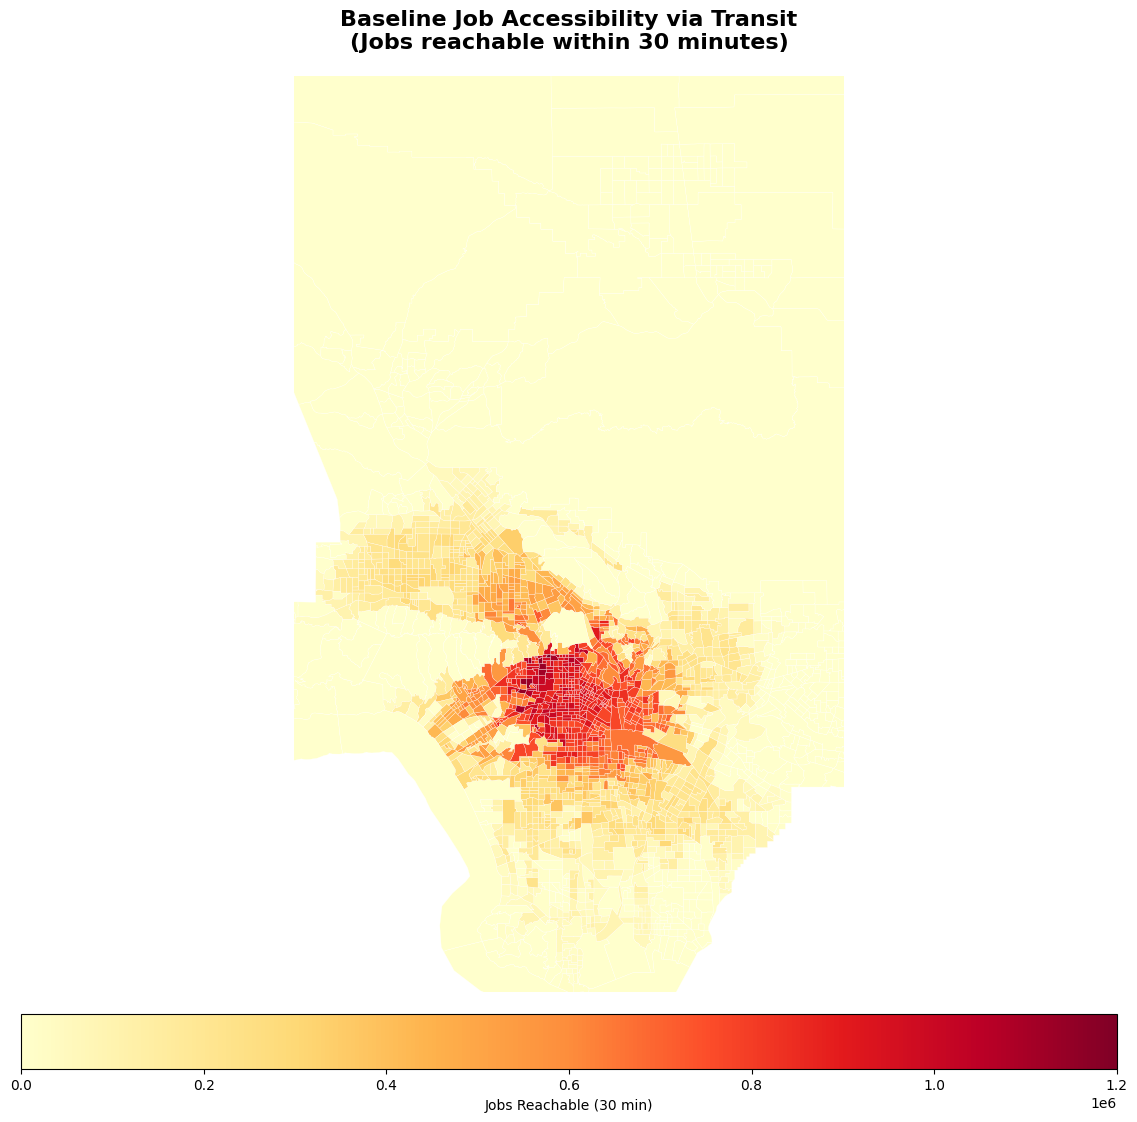

In [17]:
# Create accessibility choropleth map
print("Creating accessibility choropleth map...")

# Filter to LA County extent for mapping
la_bbox = {'min_lon': -118.7, 'max_lon': -117.9, 'min_lat': 33.7, 'max_lat': 34.8}
baseline_map = baseline_output.to_crs(config.GEOGRAPHIC_CRS)
baseline_map = baseline_map.cx[la_bbox['min_lon']:la_bbox['max_lon'], la_bbox['min_lat']:la_bbox['max_lat']]

# Create figure
fig, ax = plt.subplots(figsize=(14, 12))

# Plot accessibility choropleth
baseline_map.plot(
    column='accessibility_baseline',
    ax=ax,
    legend=True,
    cmap='YlOrRd',
    edgecolor='white',
    linewidth=0.2,
    missing_kwds={'color': 'lightgray'},
    legend_kwds={
        'label': 'Jobs Reachable (30 min)',
        'orientation': 'horizontal',
        'pad': 0.02,
        'shrink': 0.8
    }
)

# Set extent and labels
ax.set_xlim(la_bbox['min_lon'], la_bbox['max_lon'])
ax.set_ylim(la_bbox['min_lat'], la_bbox['max_lat'])
ax.set_title('Baseline Job Accessibility via Transit\n(Jobs reachable within 30 minutes)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.axis('off')

plt.tight_layout()
output_fig_path = config.OUTPUTS_FIGURES / 'baseline_accessibility_map.png'
plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
print(f"  ✓ Saved to {output_fig_path.relative_to(config.ROOT)}")
plt.show()

### Visualization 2: Accessibility Distribution

Histogram and KDE plot showing the distribution of baseline accessibility values.

Creating accessibility distribution plot...
  ✓ Saved to outputs/figures/baseline_accessibility_distribution.png


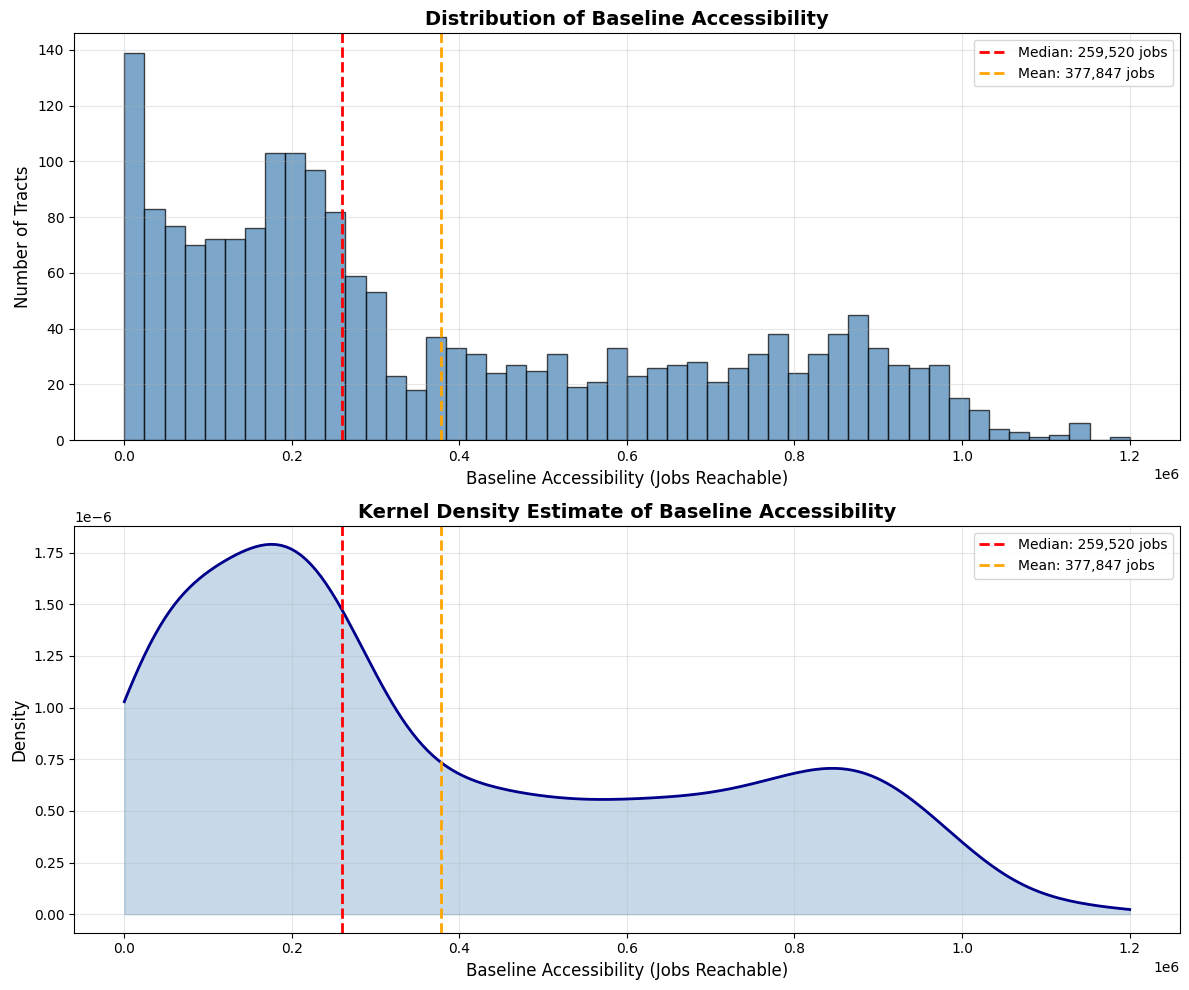


Summary Statistics:
  Total tracts: 2,498
  Tracts with accessibility > 0: 1,922
  Tracts with zero accessibility: 576
  Mean accessibility: 377,847 jobs
  Median accessibility: 259,520 jobs
  Std deviation: 305,679 jobs
  25th percentile: 135,427 jobs
  75th percentile: 632,210 jobs
  90th percentile: 866,890 jobs
  95th percentile: 933,729 jobs


In [18]:
# Create distribution plot (histogram + KDE)
print("Creating accessibility distribution plot...")

# Filter out zeros and NaN for better visualization
accessibility_clean = baseline_output['accessibility_baseline'].dropna()
accessibility_clean = accessibility_clean[accessibility_clean > 0]

# Create figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Histogram
axes[0].hist(accessibility_clean, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(accessibility_clean.median(), color='red', linestyle='--', linewidth=2, 
                label=f'Median: {accessibility_clean.median():,.0f} jobs')
axes[0].axvline(accessibility_clean.mean(), color='orange', linestyle='--', linewidth=2, 
                label=f'Mean: {accessibility_clean.mean():,.0f} jobs')
axes[0].set_xlabel('Baseline Accessibility (Jobs Reachable)', fontsize=12)
axes[0].set_ylabel('Number of Tracts', fontsize=12)
axes[0].set_title('Distribution of Baseline Accessibility', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# KDE plot
from scipy import stats
if len(accessibility_clean) > 0:
    kde = stats.gaussian_kde(accessibility_clean)
    x_range = np.linspace(accessibility_clean.min(), accessibility_clean.max(), 200)
    axes[1].plot(x_range, kde(x_range), linewidth=2, color='darkblue')
    axes[1].fill_between(x_range, kde(x_range), alpha=0.3, color='steelblue')
    axes[1].axvline(accessibility_clean.median(), color='red', linestyle='--', linewidth=2, 
                    label=f'Median: {accessibility_clean.median():,.0f} jobs')
    axes[1].axvline(accessibility_clean.mean(), color='orange', linestyle='--', linewidth=2, 
                    label=f'Mean: {accessibility_clean.mean():,.0f} jobs')
    axes[1].set_xlabel('Baseline Accessibility (Jobs Reachable)', fontsize=12)
    axes[1].set_ylabel('Density', fontsize=12)
    axes[1].set_title('Kernel Density Estimate of Baseline Accessibility', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
output_fig_path = config.OUTPUTS_FIGURES / 'baseline_accessibility_distribution.png'
plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
print(f"  ✓ Saved to {output_fig_path.relative_to(config.ROOT)}")
plt.show()

# Print summary statistics
print(f"\nSummary Statistics:")
print(f"  Total tracts: {len(baseline_output):,}")
print(f"  Tracts with accessibility > 0: {len(accessibility_clean):,}")
print(f"  Tracts with zero accessibility: {(baseline_output['accessibility_baseline'] == 0).sum():,}")
print(f"  Mean accessibility: {accessibility_clean.mean():,.0f} jobs")
print(f"  Median accessibility: {accessibility_clean.median():,.0f} jobs")
print(f"  Std deviation: {accessibility_clean.std():,.0f} jobs")
print(f"  25th percentile: {accessibility_clean.quantile(0.25):,.0f} jobs")
print(f"  75th percentile: {accessibility_clean.quantile(0.75):,.0f} jobs")
print(f"  90th percentile: {accessibility_clean.quantile(0.90):,.0f} jobs")
print(f"  95th percentile: {accessibility_clean.quantile(0.95):,.0f} jobs")

## Part 5: Summary and Checkpoint

**This notebook has produced the frozen baseline accessibility dataset.**

**Key outputs**:
1. ✅ `baseline_accessibility.parquet` - Frozen baseline dataset
2. ✅ `baseline_accessibility_map.png` - Choropleth map
3. ✅ `baseline_accessibility_distribution.png` - Distribution plot

**Next steps**:
- Notebook 02: Generate candidate corridors
- Notebook 03: Compute counterfactual accessibility (relative to this baseline)
- Notebook 04: Optimize corridor selection

**Important**: This baseline is FROZEN. All future analysis will reference this exact dataset.